# Load & Parse Data

In [5]:
import importlib
import utils.parse_data  

importlib.reload(utils.parse_data)

<module 'utils.parse_data' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/parse_data.py'>

In [6]:
from utils.parse_data import parse_dataset
from pathlib import Path

data_path = Path('../data/pooled_stratified_share_vc')
X_train, Y_train, X_test, Y_test, device = parse_dataset(root_dir=data_path, M=50, H=3, normalize=True, stride=1, test_ratio=0.2,
                                                         test_subjects=None, random_state=42, verbose=True)

Using dataset path: ../data/pooled_stratified_share_vc
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2880 runs from 8 subjects
Subjects: ['subjA2s60K-Hhm', 'subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjsRowSC6dc4', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2880
Loading time: 5.27 seconds
Device: cuda
Normalizing dataset...
Building sliding windows...
Splitting by subject...
Train subjects: ['subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjQX6R7rImeb', 'subjxpYwO4azeZ', 'subjtySNgRhV65', 'subjOenz4SHyaO']
Test subjects : ['subjsRowSC6dc4', 'subjA2s60K-Hhm']
Train runs: 2144
Test runs : 736
Final shapes - Train: (373056, 50, 23), (373056, 3, 23) | Test: (128064, 50, 23), (128064, 3, 23)


In [9]:
from models.transformer.transformer_api_library import transformer_model_generator, TransformerPredictorAPI

# Build transformer

model = transformer_model_generator(
    n_roi=X_train.shape[2],
    M=50,
    H=3,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1,
)

model = model.to(device)

In [10]:
from utils.training import train_forecasting_model

# Train Model
model = train_forecasting_model(
    model,
    X_train,
    Y_train,
    X_val=X_test,
    Y_val=Y_test,
    batch_size=512,
    num_epochs=5,
    device=device,
)

  Epoch  1 | train: 0.243269 | val: 0.213274


  Epoch  2 | train: 0.226014 | val: 0.210581


  Epoch  3 | train: 0.221631 | val: 0.209422


  Epoch  4 | train: 0.218738 | val: 0.209269


  Epoch  5 | train: 0.216430 | val: 0.209794
  No improvement (1/5)
  Best val loss: 0.209269 | weights restored


Histogram Method

In [ ]:
from utils.measures import fit_histogram_proba_adapter

# Wrap with API
config = {
    "window_size": 50,
    "predict_step": 3,
    "output_horizon": 3,
    "input_dim": X_train.shape[2],
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dropout": 0.1,
}

model_api = TransformerPredictorAPI(
    model=model,
    config=config,
    stats={},
    device=device,
)

# Build histogram likelihood adapter
di_model = fit_histogram_proba_adapter(
    base_model=model_api,
    X_calib=X_test,
    Y_calib=Y_test,
    n_bins=50,
    flatten_input=False,
)

Neural Network Method

In [ ]:
from utils.measures import FlowPredictorAPI

model_api = TransformerPredictorAPI(
    model=model,
    config=config,
    stats={},
    device=device,
)

di_model = FlowPredictorAPI(
    base_model=model_api,
    device=device,
)

In [17]:
import importlib
import utils.measures  

importlib.reload(utils.measures)

<module 'utils.measures' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/measures.py'>

In [ ]:
from utils.measures import compute_di_from_log_prob_api

DI_flow = compute_di_from_log_prob_api(
    model=di_model,
    X=X_test,
    Y=Y_test,
    horizon_idx=0,
    reduction_mode="zero",
)

Computing DI: 100%|██████████| 529/529 [01:26<00:00,  6.14it/s]


In [27]:
from utils.measures import make_reduced_input
import numpy as np

R = X_test.shape[2]
for i in range(5):
    X_red = make_reduced_input(X_test, source_roi=i, mode="zero")
    pred_full = di_model.predict(X_test)
    pred_red = di_model.predict(X_red)

    delta = np.mean(np.abs(pred_full - pred_red), axis=(0, 1))
    print(i, delta)

0 [0.373051   0.02764125 0.04245474 0.02798601 0.03164723 0.03323226
 0.02463615 0.03255457 0.03558786 0.02839073 0.02654564 0.03003098
 0.029792   0.03029003 0.03034187 0.03581499 0.02528532 0.03575794
 0.03339001 0.03198712 0.02938442 0.03138356 0.03730755]
1 [0.02913325 0.37820885 0.04079943 0.04409967 0.0247459  0.04025695
 0.03219985 0.03624526 0.02912773 0.03213155 0.03758626 0.03577933
 0.04611001 0.0390278  0.04325439 0.02395003 0.02414808 0.03560903
 0.03053609 0.05672636 0.04300603 0.02255847 0.03912922]
2 [0.0565288  0.04402411 0.3688336  0.02977014 0.03506823 0.03555623
 0.03898489 0.03776452 0.03558141 0.03026106 0.03460338 0.02950101
 0.03468749 0.02957236 0.03398161 0.03168303 0.03232707 0.03725623
 0.03575649 0.0363008  0.03890663 0.03032487 0.03239183]
3 [0.02812661 0.05039782 0.03585123 0.40409535 0.03524594 0.04332719
 0.03080967 0.0396223  0.02892923 0.0356578  0.02973755 0.03345666
 0.03705383 0.03117467 0.02713978 0.02804512 0.03461649 0.03499272
 0.03136039 0.041

In [19]:
DI_flow.shape

# DI_flow


(23, 23)

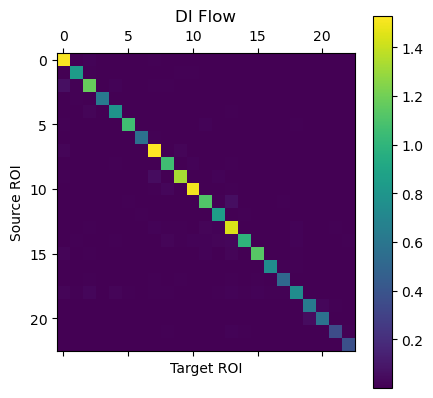

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.matshow(np.abs(DI_flow) )
plt.colorbar()
plt.title("DI Flow")
plt.xlabel("Target ROI")
plt.ylabel("Source ROI")
plt.show()